# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Import data
dfraw=pd.read_pickle("WM811K.pkl")

In [2]:
dfraw.info()

dfraw.head()

dfraw.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dieSize         811457 non-null  float64
 1   failureType     811457 non-null  object 
 2   lotName         811457 non-null  object 
 3   trainTestLabel  811457 non-null  object 
 4   waferIndex      811457 non-null  float64
 5   waferMap        811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
811452,600.0,Edge-Ring,lot47542,Test,23.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811453,600.0,Edge-Loc,lot47542,Test,24.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,..."
811454,600.0,Edge-Ring,lot47542,Test,25.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811455,600.0,"[0, 0]",lot47543,"[0, 0]",1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,..."
811456,600.0,"[0, 0]",lot47543,"[0, 0]",2.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."


<table>
    <tr>
        <th>Column</th>
        <th>Description</th>
        <th>Type</th>
    </tr>
    <tr>
        <td>lotName</td>
        <td>Name of lot of wafers processed as a batch. Numbered by process order.</td>
        <td>Object</td>
    </tr>
    <tr>
        <td>waferIndex</td>
        <td>Physical location of wafer in a lot (1-25)</td>
        <td>Float64</td>
    </tr>
    <tr>
        <td>waferMap</td>
        <td>List of whether defect is present by location on wafer (1 is yes, 0 is no)</td>
        <td>Object</td>
    </tr>
    <tr>
        <td>failureType</td>
        <td>Classification of defects based on wafer map</td>
        <td>Object</td>
    </tr>
</table>

In [3]:
#  Columns
Rename = {'lotName':'Lot',
          'waferIndex':'Slot',
          'failureType':'Defect_Class',
          'waferMap':'Wafer_Map'}
dfraw.rename(columns=Rename,inplace=True)

# Drop dieSize
del dfraw['dieSize']

### Slot Column

Drop blank and null values. Confirm Slot only has integers

In [4]:
import numpy as np

# Replace blank with nulls + drop rows with nulls
dfraw['Slot'] = dfraw['Slot'].replace('', np.nan)
dfraw = dfraw.dropna(subset=['Slot'])

# Inspect Slot column for integers
value_counts_slot = dfraw['Slot'].value_counts().sort_index()
print(value_counts_slot)

# Change to integer data type
dfraw['Slot'] = dfraw['Slot'].astype(int)

Slot
1.0     32516
2.0     32663
3.0     32621
4.0     32714
5.0     32701
6.0     32745
7.0     32672
8.0     32650
9.0     32636
10.0    32586
11.0    32637
12.0    32598
13.0    32381
14.0    32353
15.0    32301
16.0    32362
17.0    32333
18.0    32333
19.0    32285
20.0    32290
21.0    32320
22.0    32312
23.0    32202
24.0    32197
25.0    32049
Name: count, dtype: int64


No blank/null rows dropped. All values are integers. Not every slot has equal number of occurences. This means not every lot is a full 25 wafer lot. Let's visualize it.

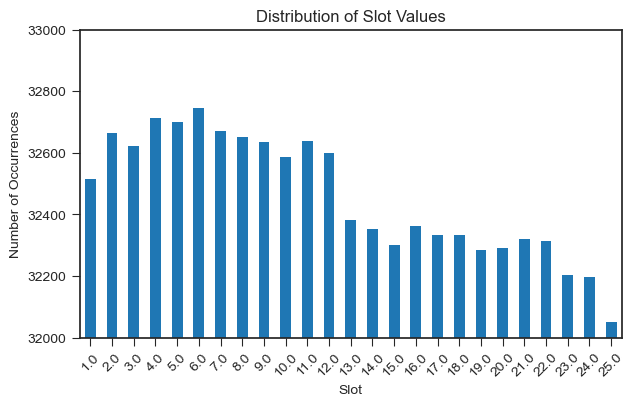

In [5]:
# Distribution of Slot Values
plt.figure(figsize=(7, 4))
plt.style.use('seaborn-v0_8-ticks')
value_counts_slot.plot(kind='bar')
plt.xlabel('Slot')
plt.ylim(32000,33000)
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Slot Values')
plt.xticks(rotation=45)
plt.show()

Not every lot has same number of wafers, the sharp downshift from 12 to 13 suggests some lots are run as  half 12 wafer only lots.
This will not impact our analysis of the 1st wafer effect as we will only observe variations in Slot 1 vs other slots. Number of Occurences of Slot 1 is less than Slot 2, suggesting that some lots are run without wafers in Slot 1 position, likely to reduce impact of 1st wafer effects.

### Lot Column

Similar data cleaning for Lot Column below: dropping nulls/blanks and changing to integer type

In [6]:
# Replace blank with NaN + drop nulls
dfraw['Lot'] = dfraw['Lot'].replace('', np.nan)
dfraw = dfraw.dropna(subset=['Lot'])

# Inspect Lot column
value_counts_slot = dfraw['Lot'].value_counts().sort_index()
print(value_counts_slot)

Lot
lot1        25
lot10       25
lot100      25
lot10000     2
lot10001     2
            ..
lot9995     25
lot9996     25
lot9997     23
lot9998     23
lot9999     23
Name: count, Length: 46293, dtype: int64


No rows were dropped. There are 46,293 unique lots. We need to modify this column to drop the lot prefix in the value, then we can check if all values are integers, and change data type to integer. Since the name of the lot is an integer starting from 1 in order of processing, We can use 'Lot' as a pseudo time axis

In [7]:
# Remove the 'lot' prefix
dfraw['Lot'] = dfraw['Lot'].str.replace('lot', '')

# Change to integer data type
dfraw['Lot'] = dfraw['Lot'].astype(int)

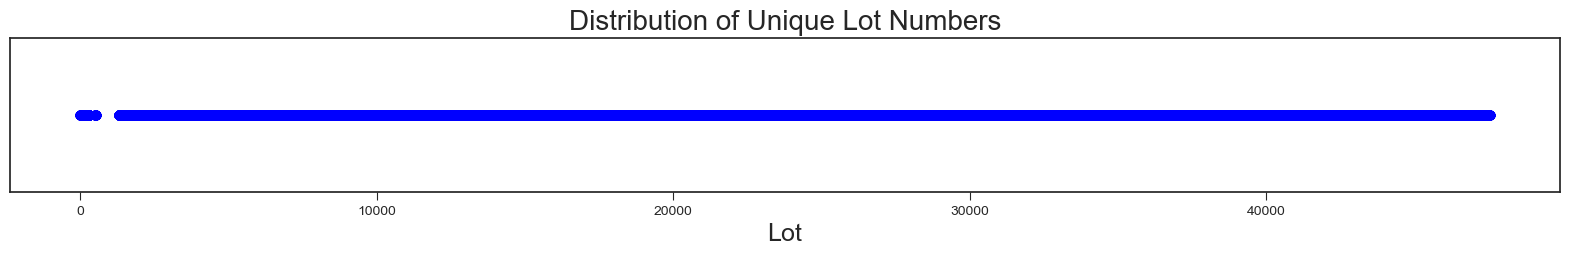

In [8]:
# Plot lot number
plt.figure(figsize=(20, 2))
plt.scatter(dfraw['Lot'], [0] * len(dfraw), color='blue')
plt.xlabel('Lot', fontsize = 18)
plt.title('Distribution of Unique Lot Numbers', fontsize = 20)
plt.yticks([])
plt.show()

So, all our Lot values fall between 1 and 47,543, with 46,293 unique values. Blank spot on number line above shows some lots were not sampled, especially near ~1000 range for unknown reasons.

### Defect_Class Column

Defects are classified into several values, and defects with no clear shape/location are classified as Random. "[0 0]" represents wafermaps that were not classified, and "none" represents wafer maps that were classified, but no significant defects were observed. We will use the "none" data to calculate a baseline level of defects in EDA Part 2, and will only drop the unclassified data.

In [9]:
# Ensure column is a string
dfraw['Defect_Class'] = dfraw['Defect_Class'].astype(str)
dfraw = dfraw[dfraw['Defect_Class'] != '[0 0]']
shape = dfraw.shape
print(f'Shape after dropping unclassified defect values: {shape}')

Shape after dropping unclassified defect values: (172950, 5)


We have dropped 638507 rows of unclassified data.

### Wafer_Map Column

Clean null / empty list / nonlist entries.

In [10]:
# Check for null, empty lists, nonlist entries.
Null = dfraw['Wafer_Map'].isnull()
NonlistorEmpty = dfraw['Wafer_Map'].apply(lambda x: len(x) == 0 if isinstance(x, list) else False)

# Boolean combination
Cleaner = Null | NonlistorEmpty

# Remove rows with null, empty lists, or nonlist entries.
dfraw = dfraw[~Cleaner]

No rows were dropped.

### Visualization of Wafer Maps

As a final step, let's visualize our wafer map data. The goal is the ensure defect classification is accurate visually. 2nd goal is to ensure that defects classified as "none" show no significant defect patterns and can appropriately be used to calculate a baseline level of defects

In [11]:
# Create dataframe with Defect_Class = 'none' only
dfNone = dfraw[dfraw['Defect_Class'] == 'none']

# Create dataframe with classified Defect_Class
dfClassified = dfraw[dfraw['Defect_Class'] != 'none']

In [12]:
# Define function for repeatability of plotting
def plot_wafer_maps(df, number_of_subplots):
    """
    
    Plots first number_of_subplots of wafer map images from df dataframe using Wafer_Map and Defect_Class columns.
    Creates grid of subplots. Please only input number_of_subplots in units of 10.
    
    """
    dfreset = df.reset_index()
    nrows = int(number_of_subplots / 10)
    fig, ax = plt.subplots(nrows = nrows, ncols = 10, figsize=(20, nrows * 2))
    ax = ax.ravel(order='C')         #This is necessary to loop all subplots with 1 index
    for i in range(number_of_subplots):
        img = dfreset.Wafer_Map[i]
        ax[i].imshow(img)
        title = f'{dfreset.index[i]} - {dfreset.Defect_Class[i]}'
        ax[i].set_title(title)
        ax[i].axis('off')
    plt.tight_layout()
    plt.show() 

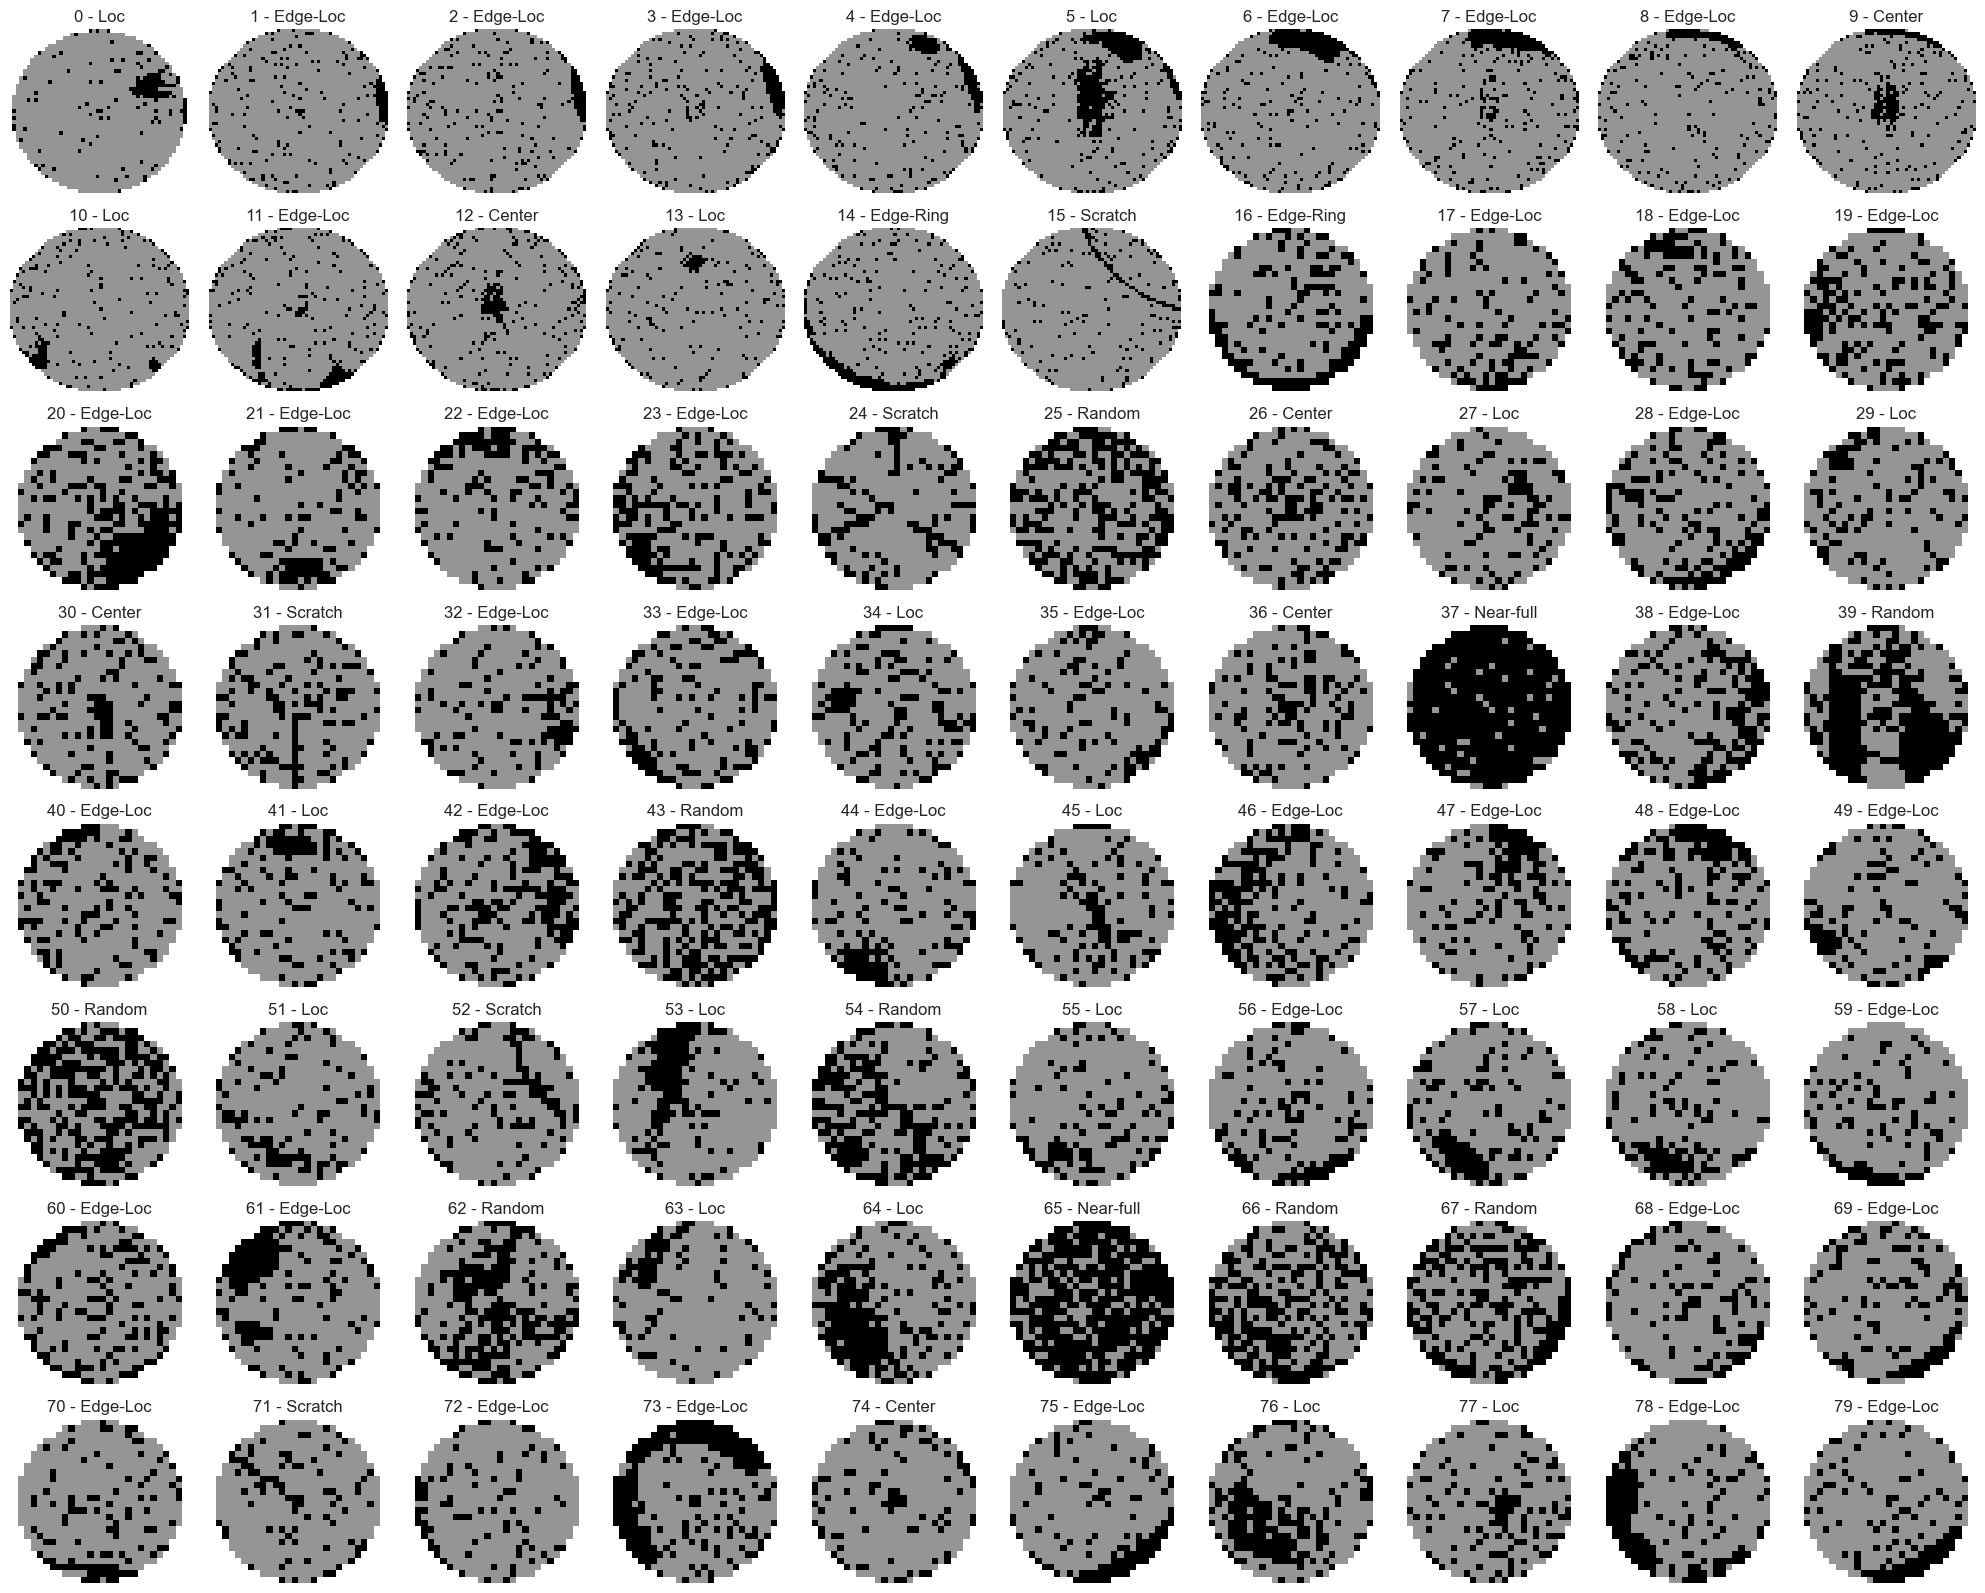

In [13]:
# Plot Classified Data
plot_wafer_maps(dfClassified, 80)

Above plots show that wafers can have more than 1 type of classified defect. For example, index 3 shows Edge-Loc and Loc defects, but is labeled only as Loc. This is a limitation of our dataset which only labels the largest defect appropriately since only 1 defect classification per wafer map is allowed. Therefore, wafers with multiple defect patterns may affect our results in EDA Part 2 by showing larger than actual die yield impact.

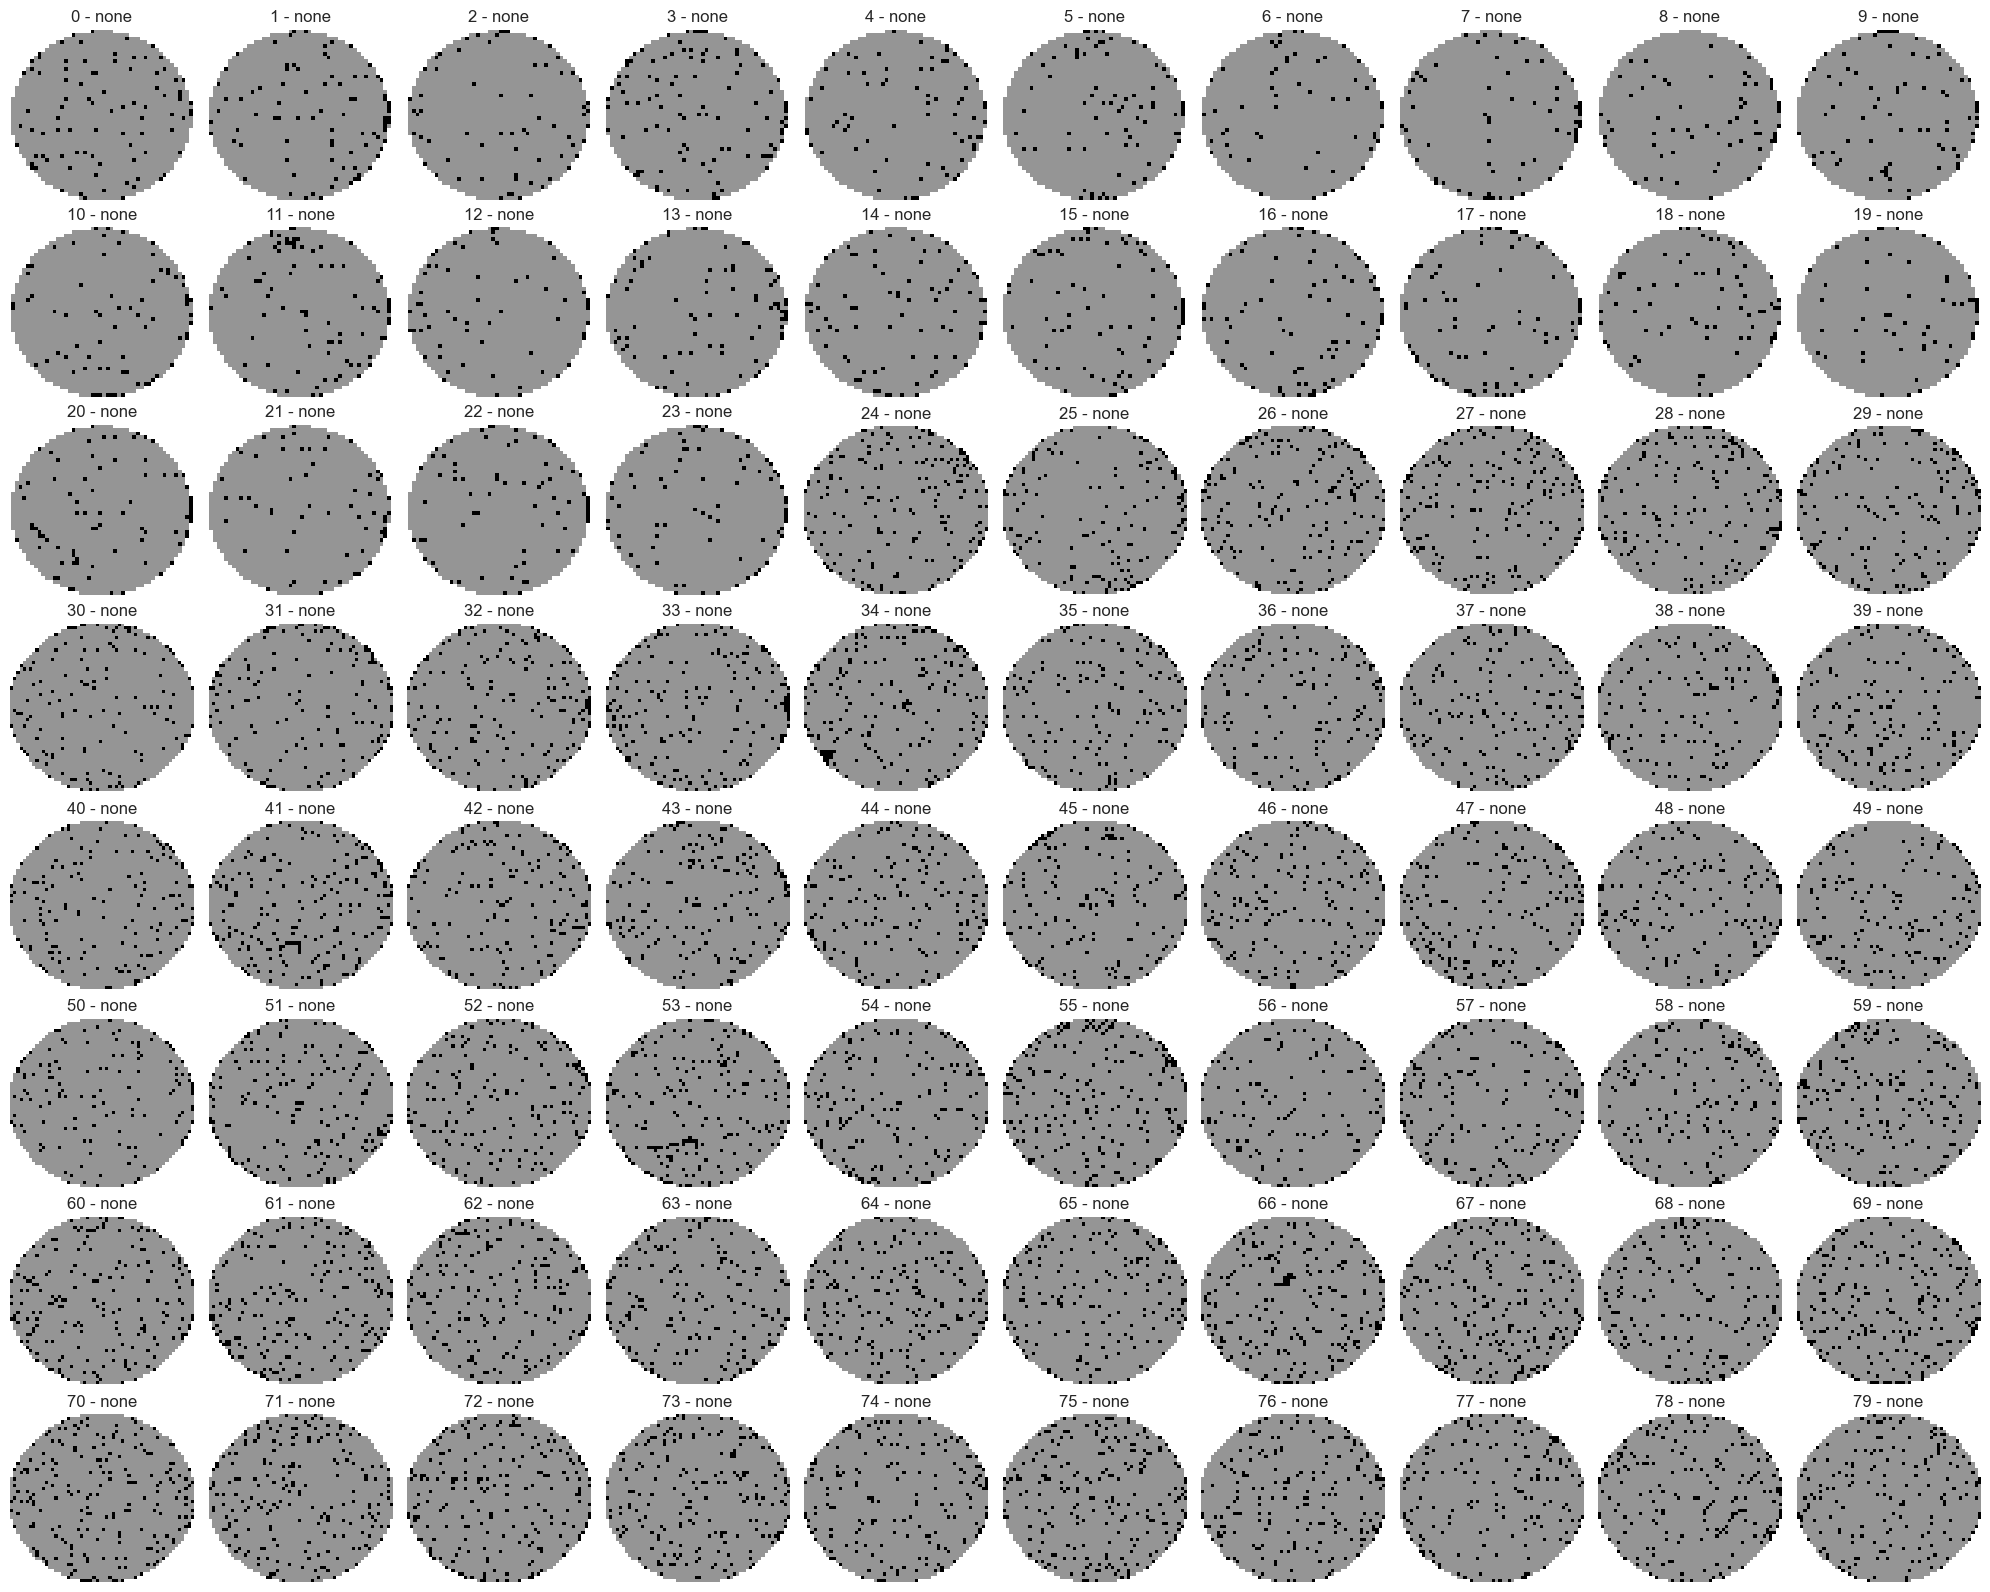

In [14]:
#Plot None Data
plot_wafer_maps(dfNone, 80)

Visually, we have verified that "none" classification of defects does not include any defect patterns. This would be good to use to determine baseline level of defects/die yield.

Another note, not all wafermaps are the same dimensions, so let's check where our distributions lie in case cleaning is needed.

In [15]:
def dimension(x):
    '''
    
    This will return the dimension of a 2D array x.
    
    '''
    rows = np.size(x,axis=0)
    columns = np.size(x,axis=1)
    return rows,columns

In [16]:
# Create dataframe of wafer map dimensions
dfdimensions=dfraw.Wafer_Map.apply(dimension)

# Display value counts
value_counts_dimensions = dfdimensions.value_counts().sort_index()
display(value_counts_dimensions)

Wafer_Map
(15, 3)         1
(18, 4)         1
(18, 44)        1
(22, 35)        2
(22, 50)      899
             ... 
(143, 132)     10
(152, 172)     11
(153, 187)      2
(155, 175)     48
(212, 84)       8
Name: count, Length: 346, dtype: int64

The smallest wafer map we have is 15x3. This resolution is very low, and it may throw off our die yield metrics. Let's remove wafer maps that have dimensions that are relatively too small.

In [17]:
# Calculate Area from dimensions
dfarea = dfdimensions.apply(lambda dimensions: dimensions[0] * dimensions[1])

# Display value counts of area
value_counts_area = dfarea.value_counts().sort_index()
display(value_counts_area)

Wafer_Map
45        1
72        1
312       1
405       1
432       1
         ..
19710     9
24888     3
26144    11
27125    48
28611     2
Name: count, Length: 314, dtype: int64

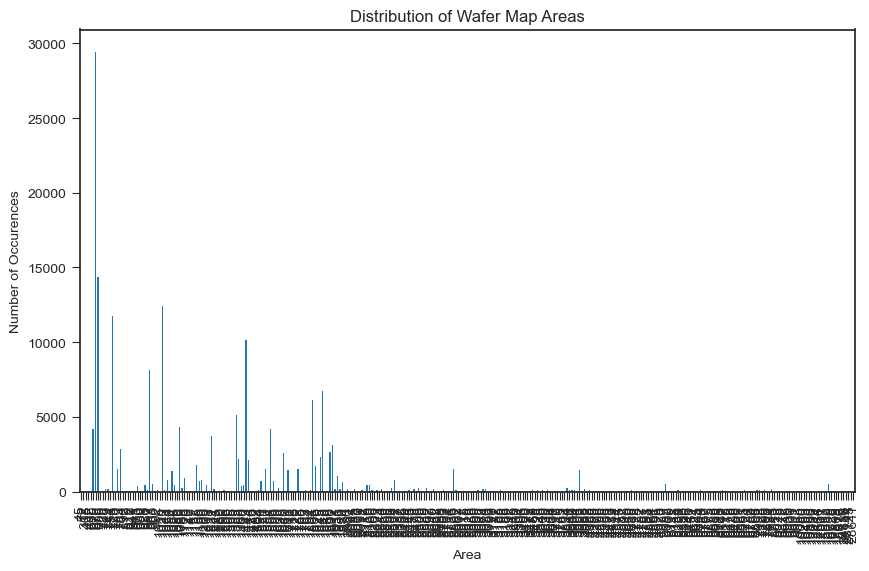

In [18]:
# Plot area in bar chart
plt.figure(figsize=(10, 6))
value_counts_area.plot(kind='bar')
plt.xlabel('Area')
plt.ylabel('Number of Occurences')
plt.title('Distribution of Wafer Map Areas')
plt.show()

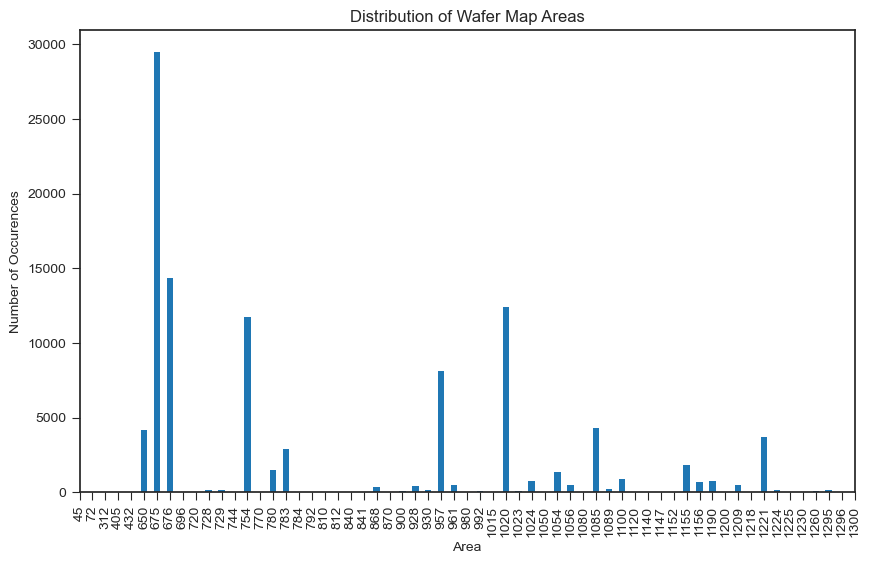

In [19]:
#Plot area in bar chart
plt.figure(figsize=(10, 6))
value_counts_area.plot(kind='bar')
plt.xlabel('Area')
plt.ylabel('Number of Occurences')
plt.xlim(0,60)
plt.title('Distribution of Wafer Map Areas')
plt.show()

Highest counts of area are at 675. We also have lots of data at 650, so let's remove any rows with area less than 650.

In [20]:
# Remove rows where area is less than 650 
dfraw = dfraw[dfarea >= 650]


5 rows were dropped. Now let's save our final clean data.

In [21]:
import pickle
dfcleaned = dfraw

with open('WM811KClean.pkl','wb') as cleanfile:
    pickle.dump(dfcleaned, cleanfile)

### Data Dictionary

<table>
    <tr>
        <th>Column</th>
        <th>Description</th>
        <th>Type</th>
    </tr>
    <tr>
        <td>Lot</td>
        <td>Name of lot of wafers processed as a batch. Numbered by process order.</td>
        <td>int64</td>
    </tr>
    <tr>
        <td>Slot</td>
        <td>Physical location of wafer in a lot (1-25)</td>
        <td>Int64</td>
    </tr>
    <tr>
        <td>Wafer_Map</td>
        <td>List of whether defect is present by location on wafer (2 is yes, 1 is no, 0 is background)</td>
        <td>Object</td>
    </tr>
    <tr>
        <td>Defect_Class</td>
        <td>Classification of defects based on wafer map</td>
        <td>Object</td>
    </tr>
</table>

### Accomodating for Edge Dies

To understand the impact of our defects, we need to first accomodate for the zero yield on edge dies. Let's visualize Defect_Class = 'None' to do so.

<class 'pandas.core.frame.DataFrame'>
Index: 172945 entries, 0 to 811454
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Defect_Class    172945 non-null  object
 1   Lot             172945 non-null  int32 
 2   trainTestLabel  172945 non-null  object
 3   Slot            172945 non-null  int32 
 4   Wafer_Map       172945 non-null  object
dtypes: int32(2), object(3)
memory usage: 6.6+ MB


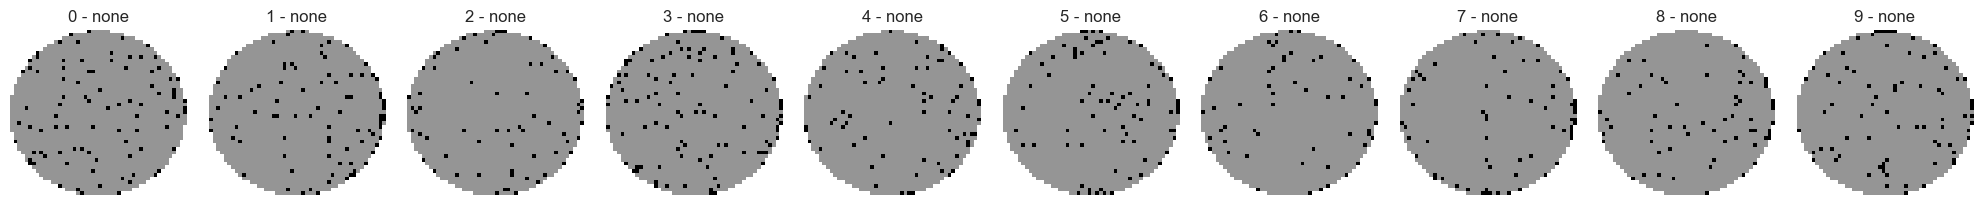

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Import cleaned data
dfcleaned=pd.read_pickle("WM811KClean.pkl")

# Data info as FYI
dfcleaned.info()
 
# Create dataframe with Defect_Class = 'none' only
dfNone = dfcleaned[dfcleaned['Defect_Class'] == 'none']

# Plot 'none' Data w/function from EDA Part 1
plot_wafer_maps(dfNone, 10)

Print array for '0 - none':

In [23]:
# First row of 'none'
firstrow = dfNone.loc[0, 'Wafer_Map']

# Set options to display whole array
np.set_printoptions(threshold=np.inf)

# Print array
print("0 - none:\n", firstrow)

0 - none:
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1
  1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2
  1 1 1 2 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 

We have label 2 for defects, 1 for no defects, and 0 for background. Since our wafer maps are different dimensions, it complicates how we can ignore edge dies. For simplicity, we will choose **3** first/last rows and **3** first/last 1 or 2 values in each row to sufficiently ignore zero edge die yields. Let's visualize this to ensure it appropriately covers the edge for '0 - none' wafer map:

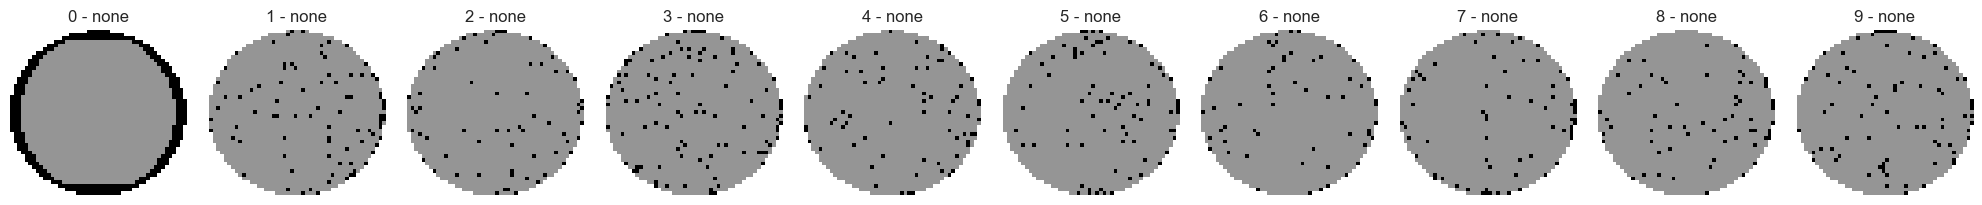

In [24]:
# Replace 1/2 with 1
firstrow[firstrow == 2] = 1

def Edge_die_transformation_two(firstrow):
    """
    
    Transforms edge regions in a 2D wafer map array with value of 2. Exclusion value of 3.
    
    """
    # Replace 1 in first/last 3 rows with 2
    firstrow[:3, :][firstrow[:3, :] == 1] = 2
    firstrow[-3:, :][firstrow[-3:, :] == 1] = 2

    # Replace 1/2 in first/last 3 entries in each row with 2
    for row in range(firstrow.shape[0]):
    
        # Index of first 3 entries of 1/2, Replace with 2
        findex = np.where((firstrow[row] == 1) | (firstrow[row] == 2))[0][:3]
        firstrow[row, findex] = 2
    
        # Index of last 3 entries of 1/2, Replace with 2
        lindex = np.where((firstrow[row] == 1) | (firstrow[row] == 2))[0][-3:]
        firstrow[row, lindex] = 2
    return firstrow

firstrow = Edge_die_transformation_two(firstrow)

# Replace data and plot
dfNone.at[0, 'Wafer_Map'] = firstrow
plot_wafer_maps(dfNone, 10)

Based on visual inspection, exclusion value of 3 is sufficient to cover edge dies. We will use this value for all wafer maps. Let's create a new column for our yield calculations and update edge regions with 0 (setting them as background).

In [25]:
# Create backup
dfcleaned=pd.read_pickle("WM811KClean.pkl")
dfclean = dfcleaned

# New column for die yield calculations
dfclean['Wafer_Map_Yield'] = dfclean['Wafer_Map']

def Edge_die_transformation(firstrow):
    """
    
    Transforms edge regions in a 2D wafer map array with value of 0. Exclusion value of 3.
    
    """
    # Replace 1 in first/last 3 rows with 0
    firstrow[:3, :][firstrow[:3, :] == 1] = 0
    firstrow[-3:, :][firstrow[-3:, :] == 1] = 0

    # Replace 1/2 in first/last 3 entries in each row with 0
    for row in range(firstrow.shape[0]):
    
        # Index of first 3 entries of 1/2, Replace with 0
        findex = np.where((firstrow[row] == 1) | (firstrow[row] == 2))[0][:3]
        firstrow[row, findex] = 0
    
        # Index of last 3 entries of 1/2, Replace with 0
        lindex = np.where((firstrow[row] == 1) | (firstrow[row] == 2))[0][-3:]
        firstrow[row, lindex] = 0
    return firstrow

In [26]:
# Apply transformation
dfclean['Wafer_Map_Yield'] = dfclean['Wafer_Map_Yield'].apply(Edge_die_transformation)

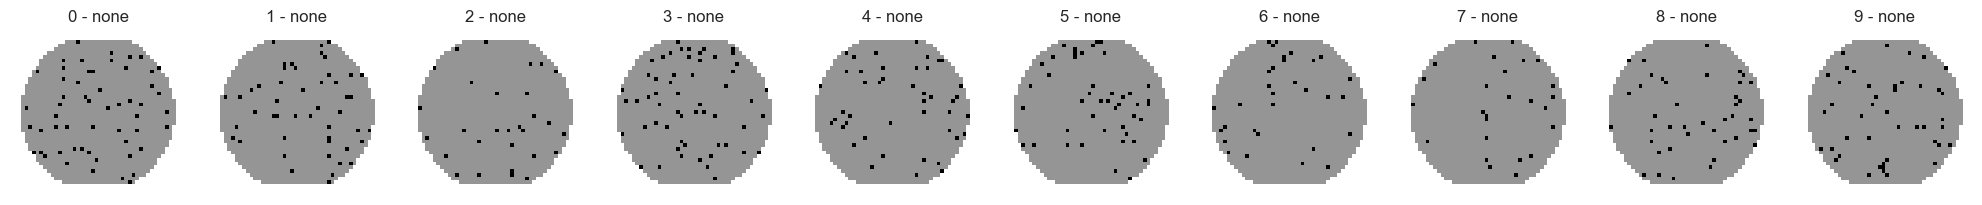

In [27]:
# Check validity
dfNone = dfclean[dfclean['Defect_Class'] == 'none']
plot_wafer_maps(dfNone, 10)

### Calculating Baseline Level of Defects

To accurately understand the impact that certain defect patterns have on the wafer, we must accomodate for baseline level of defects that are expected. We will use the 'none' data to find this value.

In [28]:
def defect_percent(row):
    """
    
    Calculates percent of defects given a 2D wafer map array.
    
    """
    # Count defects
    count = np.sum(row == 2)
    
    # Count total dies
    total_count = np.sum((row == 1) | (row == 2))
    
    # Calculate percent of defects
    defect_percent = (count / total_count) * 100

    return defect_percent

# Apply calculations to df
dfclean['Die_Impact_Percent'] = dfclean['Wafer_Map_Yield'].apply(defect_percent)

# Update baseline defect table
dfNone = dfclean[dfclean['Defect_Class'] == 'none']

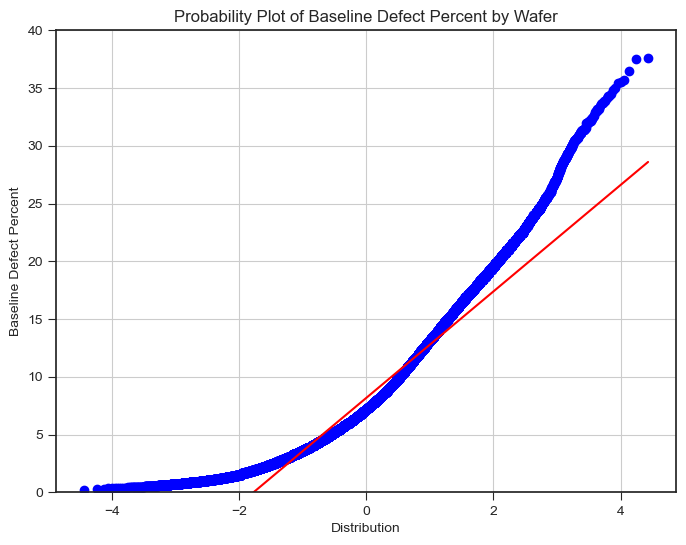

In [29]:
# Plot defect percent for baseline data
plt.figure(figsize=(8, 6))
stats.probplot(dfNone['Die_Impact_Percent'], plot=plt)
plt.title('Probability Plot of Baseline Defect Percent by Wafer')
plt.xlabel('Distribution')
plt.ylabel('Baseline Defect Percent')
plt.ylim(0,40)
plt.grid(True)
plt.show()

Probabilty plot above shows that we have wafers with close to zero defects as well as upto 37% defects in our baseline. This is expected because no manufacturing process is perfect, defects are present even in a baseline. Our median value is around 7-8% defects. However, a mean value is likely the best use for our analysis. Let's find that.

In [30]:
Baseline_Percent_Defects = dfNone['Die_Impact_Percent'].mean()
print(Baseline_Percent_Defects)

8.167330431810532


To answer our question, we have **8.17%** baseline level of defects in manufacturing, meaning 8.17% of dies will not yield on average. This manufacturing process yields relatively well at the baseline level. However, to truly understand manufacturing health, we need to determine how prevalent systematic defects are and quantify their impact on yield.

### Yield Impact of Defect Patterns 

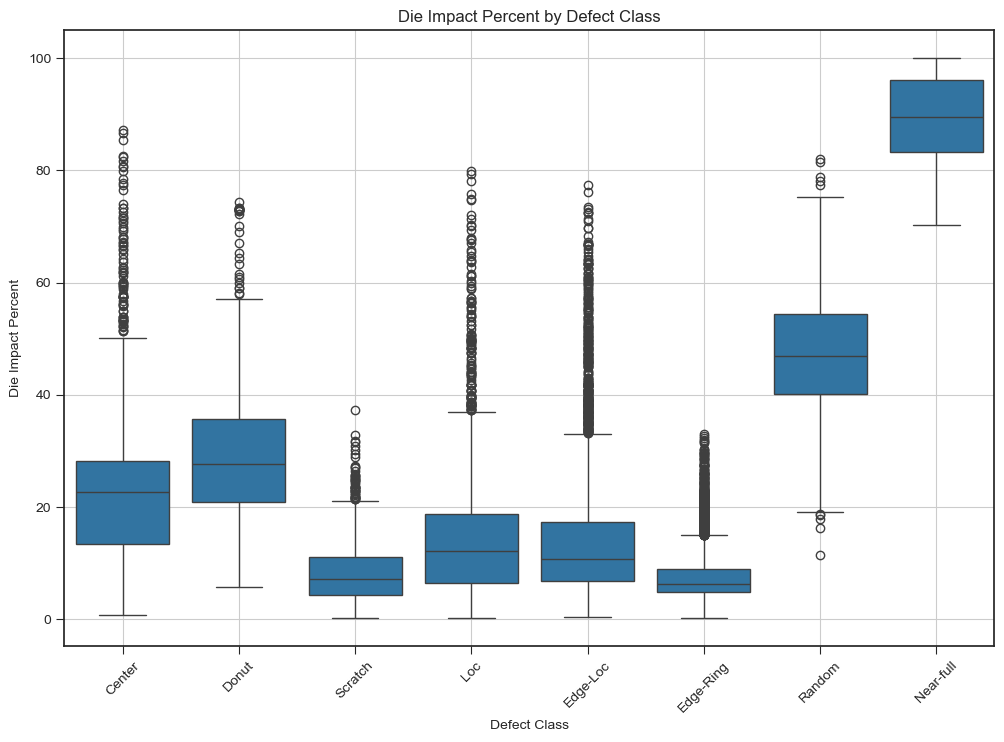

In [31]:
# Create the box plot
defect_order=['Center','Donut','Scratch','Loc','Edge-Loc','Edge-Ring','Random','Near-full']
plt.figure(figsize=(12, 8))
sns.boxplot(x='Defect_Class', y='Die_Impact_Percent', data=dfclean, order=defect_order)

# Add titles and labels
plt.title('Die Impact Percent by Defect Class')
plt.xlabel('Defect Class')
plt.ylabel('Die Impact Percent')
plt.xticks(rotation=45)
plt.grid(True)

# Display the plot
plt.show()

Let's find the average Die_Impact_Percent for each defect class after accounting for our baseline defect value of 8.17%

In [32]:
# Create new column to subtract baseline level of defects
dfclean['Defect_Die_Impact_Percent'] = dfclean['Die_Impact_Percent']

# Subtract baseline level of defects
dfclean.loc[dfclean['Defect_Class'].isin(defect_order), 'Defect_Die_Impact_Percent'] = (dfclean['Die_Impact_Percent'] - Baseline_Percent_Defects)

# Calculate average die impact of each defect type
grouped_dfclean_describe = dfclean.groupby('Defect_Class')['Defect_Die_Impact_Percent'].describe()

# Display statistics for Die_Impact_Percent
dfsummary=grouped_dfclean_describe.sort_values(by='mean', ascending=False)

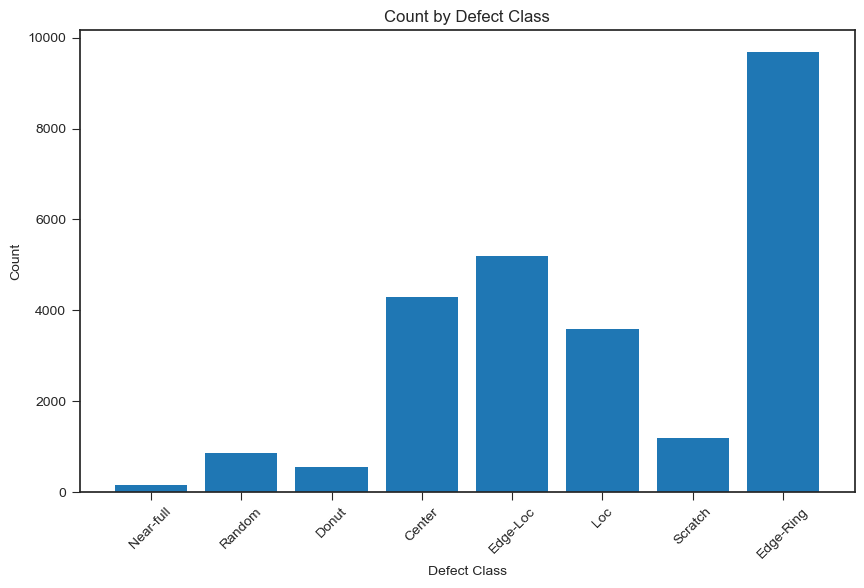

In [33]:
# Drop none data for bar chart
dfsummary_dropnone = dfsummary[dfsummary.index != 'none']

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(dfsummary_dropnone.index, dfsummary_dropnone['count'])
plt.title('Count by Defect Class')
plt.xlabel('Defect Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The box plot does a great job of showing where the distribution of die impact percent falls. However, it is not clear as to the total number of dies affected (wafer count times die impact). We need to illustrate this further to clearly identify which defect patterns are affecting our yield and costing the most product.

We will add a Normalized Die Impact metric to our summary table which will give comparitive value for total number of dies impacted by a certain Defect Class

C:\Users\custu\AppData\Local\Temp\ipykernel_18684\4172587119.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfsummary_dropnone['Normalized Die Impact'] = (dfsummary_dropnone['mean'] * dfsummary_dropnone['count']) / total_count


,count,mean,Normalized Die Impact
Defect_Class,,,
Center,4294.0,13.871231,2.334067
Random,866.0,39.086733,1.326428
Edge-Loc,5189.0,5.798170,1.178992
Loc,3593.0,5.776014,0.813246
Near-full,149.0,80.914861,0.472445
Donut,555.0,21.609727,0.469979
Scratch,1193.0,0.121045,0.005659
Edge-Ring,9680.0,-0.811660,-0.307883


C:\Users\custu\AppData\Local\Temp\ipykernel_18684\4172587119.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, dfsummary_dropnone['Normalized Die Impact'][i], f"({round(dfsummary_dropnone['mean'][i],2)},{int(dfsummary_dropnone['count'][i])})", ha='center', fontsize=12)


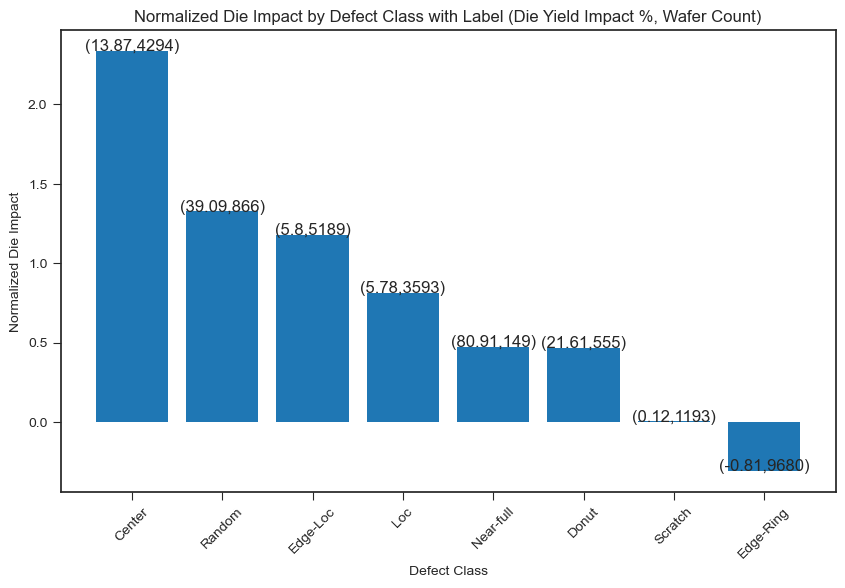

In [34]:
# Calculate a 'normalized' die impact metric for each defect class.
# We will take Die_Impact_Percent times number of wafers. Then, we will divide by total classified wafers.
total_count = dfsummary_dropnone['count'].sum()
dfsummary_dropnone['Normalized Die Impact'] = (dfsummary_dropnone['mean'] * dfsummary_dropnone['count']) / total_count

# Sort by new metric
dfsummary_dropnone=dfsummary_dropnone.sort_values(by='Normalized Die Impact', ascending=False)

# Delete columns std, 25%, 50%, 75%, max, min
dfsummary_dropnone.drop(['std', '25%', '50%', '75%', 'max', 'min'], axis=1, inplace=True)

# Display results
display(dfsummary_dropnone)

# Plot bar chart of Normalized Die Impact by Defect Class and label with (mean,count)
plt.figure(figsize=(10, 6))
plt.bar(dfsummary_dropnone.index, dfsummary_dropnone['Normalized Die Impact'])
plt.title('Normalized Die Impact by Defect Class with Label (Die Yield Impact %, Wafer Count)')
plt.xlabel('Defect Class')
plt.ylabel('Normalized Die Impact')
plt.xticks(rotation=45)
for i in range(len(dfsummary_dropnone)):
    plt.text(i, dfsummary_dropnone['Normalized Die Impact'][i], f"({round(dfsummary_dropnone['mean'][i],2)},{int(dfsummary_dropnone['count'][i])})", ha='center', fontsize=12)
plt.show()


### Conclusions on Defect Class Impact on Die Yield

As expected, Near-full defects have the highest impact on percent die yield at 81%, as nearly all the wafer is trashed with defects. However, it falls 5th on our normalized impact metric due to only having 149 wafers impacted. Generally Near-full defects are gross and obvious processing issues that are easy to catch, can cause a tool to abort/fail. Work should be done to resolve these issues, but it may not require significant resources in root cause problem identification and may not be a priority due to low wafer impact. 

Center defects have the highest Die impact, affecting 4294 wafers with 14% die impacted. This is clearly the largest problem facing this manufacturing site (normalized value of 2.33), and they should focus most of their resources in reducing and tackling these Center defects.

Random comes next with normalized value of 1.32. This is a bucket category for defect patterns that are unclassified. Random defects have 2nd highest impact on die yield at 39% with 855 wafers affected. The large whiskers on the plot show that there is a large variation in size of unclassified defect patterns in this bucket. Therefore, there may be a staggered approach to solving problems in this defect class. It will be more important to tackle larger defects within this bucket, and I would recommend more work be done to learn how to classify these larger defect patterns to improve problem identification. 

Suprisingly, Edge-Loc defects have higher die impact percent than Loc (higher wafers affected, die percent yield, and normalized die impact). This was an unexpected result as we accomodated for zero edge die yields already. This suggests that Edge-Loc patterns are fairly large and reach past the edge exclusion zone and also have a noticable impact on yield at 6% with 5189 wafers affected. This defect should be resolved as a third priority to Center and Random, followed by investigation Loc defects as 4th priority.

Donut region defects are fairly low on our list, with 22% die impacted and 555 wafers affected, it falls low on our normalized metric at 0.47. Overall, defects in the donut region are not ideal, but there are higher impact defects that should be addressed as discussion above.

Scratch defects impact a small number of dies as expected (normalized value of 0.005), as a scratch on the wafer may not be thick enough to affect lots of dies. I would  leave scratch defects as a low priority problem statement to address.

The lowest die impact defect mode is Edge-Ring. This is an expected result as Edge-Ring defects fall within or near the edge exclusion zone. While this defect has the highest number of wafers impacted, the die impact from this defect is very low. We are actually getting a negative value when subtracting the 8.17% baseline defect value. This suggests wafers with Edge-Ring defect patterns have a less than 8.17% defectivity average on the wafer. Overall, Edge-Ring defects are fairly insignficant when accounting for baseline defects and edge exclusion zone.

### Investigating Pseudo-Time Trends of Defect Class

We want to check if there are any time trends in our defect data. Lots are numeric integer labels from 1 to 47542 in the order of manufacturing. Therefore, we can use this as a pseudo time axis to investigate time trends. Lots have between 1-25 Slots in them, so we will have to find the most prevalent defect in each lot and plot this on a time trend:

In [35]:
#Drop 'None' values
dfclean_dropnone = dfclean[dfclean['Defect_Class'] != 'none']

#Group by Lot and Defect Class to count occurences + get most prevalent defect class
most_prevalent_defect = dfclean_dropnone.groupby('Lot')['Defect_Class'].agg(lambda x: x.value_counts().idxmax()).reset_index()

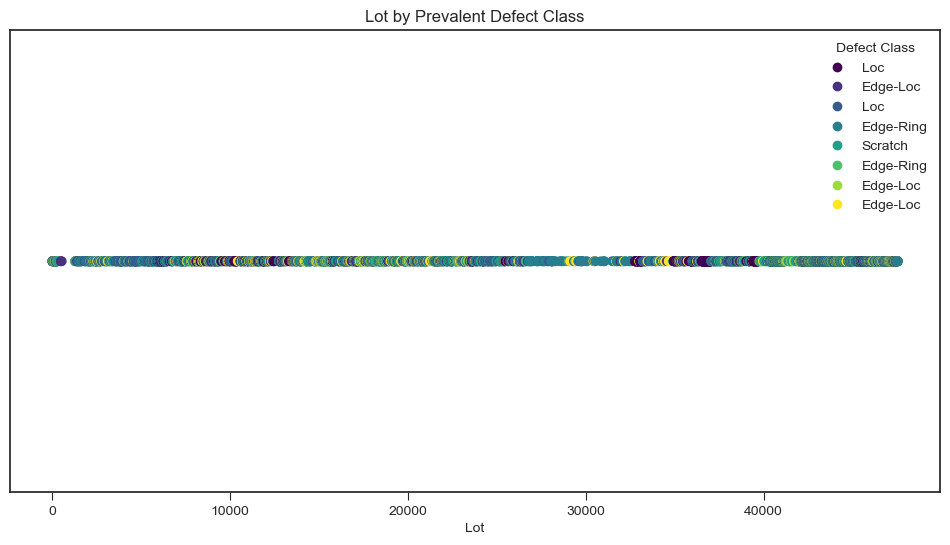

In [36]:
#Plot number line
plt.figure(figsize=(12, 6))
plot = plt.scatter(most_prevalent_defect['Lot'], [0] * len(most_prevalent_defect), c=most_prevalent_defect['Defect_Class'].astype('category').cat.codes, cmap='viridis')
plt.title('Lot by Prevalent Defect Class')
plt.xlabel('Lot')
plt.yticks([])
handles, labels = plot.legend_elements(prop="colors")
plt.legend(handles, most_prevalent_defect['Defect_Class'], title="Defect Class")
plt.show()

Overall, most defect modes occur across the entire manufacturing period. However, one thing to note is Scratch defects are prevalent near ~2500 mark. Let's modify our axis:

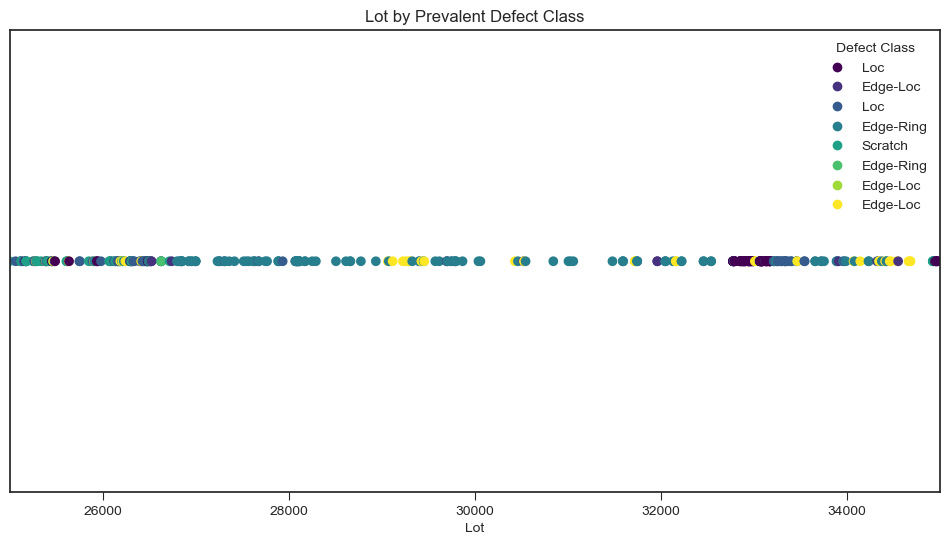

In [37]:
#Plot number line
plt.figure(figsize=(12, 6))
plot = plt.scatter(most_prevalent_defect['Lot'], [0] * len(most_prevalent_defect), c=most_prevalent_defect['Defect_Class'].astype('category').cat.codes, cmap='viridis')
plt.title('Lot by Prevalent Defect Class')
plt.xlabel('Lot')
plt.xlim([25000,35000])
plt.yticks([])
handles, labels = plot.legend_elements(prop="colors")
plt.legend(handles, most_prevalent_defect['Defect_Class'], title="Defect Class")
plt.show()

Therefore, we can see that scratch defects are prevalent around lot 26400 to 32400. To resolve a portion of these defects, we can analyze what tools or process changes occured during this time period.

### Slot order dependence on die yield

Text(0, 0.5, 'Average Defect Die Impact Percent')

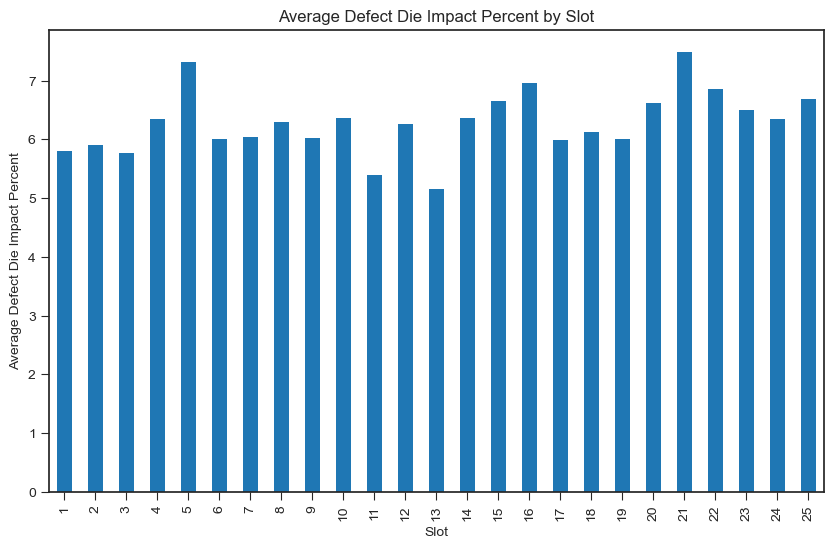

In [38]:
#Find average die impact by slot number
slot_avg = dfclean_dropnone.groupby('Slot')['Defect_Die_Impact_Percent'].mean()

#Plot bar chart
plt.figure(figsize=(10, 6))
slot_avg.plot(kind='bar')
plt.title('Average Defect Die Impact Percent by Slot')
plt.xlabel('Slot')
plt.ylabel('Average Defect Die Impact Percent')

From the bar chart above, there is no clear first wafer or last wafer effect occuring. There is no dependency on slot order for the percent of die impacted. This shows that the position in the lot is not a significant factor for defects.
However, we note that the 13th position, the middle position, has the lowest defect impact percent. This makes sense as the center position in the lot is the most optimal processing position. It will be under the best conditions and is furthest away from edge/marginal positions.